# 04 · Representative event selection — MaxDiss

From the ~1 million synthetic events, **MaxDiss** (Camus et al., 2011; Ben Alaya et al., 2014) selects a small subset that covers the full synthetic space as uniformly as possible, maximising the minimum distance between selected events.  

Selection is performed in the **full 68-dimensional space** (4 parameters × 17 gauges). Navas et al. (2024) select **625 events** for HEC-HMS + HEC-RAS simulation. Figure 7 of the paper compares synthetic vs selected events in the (Pmax, Pmed, Duration, Type) space of gauge P_27.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

_cwd = Path.cwd()
_candidates = [Path('/workspace'), _cwd, *_cwd.parents]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
    _cwd,
)
DATA_DIR  = Path(os.environ.get('HYDRA_DATA_DIR', str(REPO_ROOT / 'data')))
DATA_ROOT = DATA_DIR / 'pilot_cases' / 'm30_manzanares'

EVENTS_DIR   = DATA_ROOT / 'events'
RESULTS_DIR  = DATA_ROOT / 'results'
STATIONS_DIR = DATA_ROOT / 'stations'

print('DATA_ROOT:', DATA_ROOT)

T_VALS   = [2, 5, 10, 20, 50, 100, 500]
N_STAT   = 17
LAM      = 5.17    # Poisson rate (events/year)
XS_PT    = 6262    # Toledo Bridge cross-section
XS_R9    = 4112    # Weir No.9 cross-section


DATA_ROOT: /Users/salvadornavasfernandez/Desktop/Github/HYDRA/data/pilot_cases/m30_manzanares


Synthetic pool (~1M, sample available): 10,000
Events selected by MaxDiss: 1000
  Note: Navas et al. (2024) select 625; this dataset contains 1000 events.


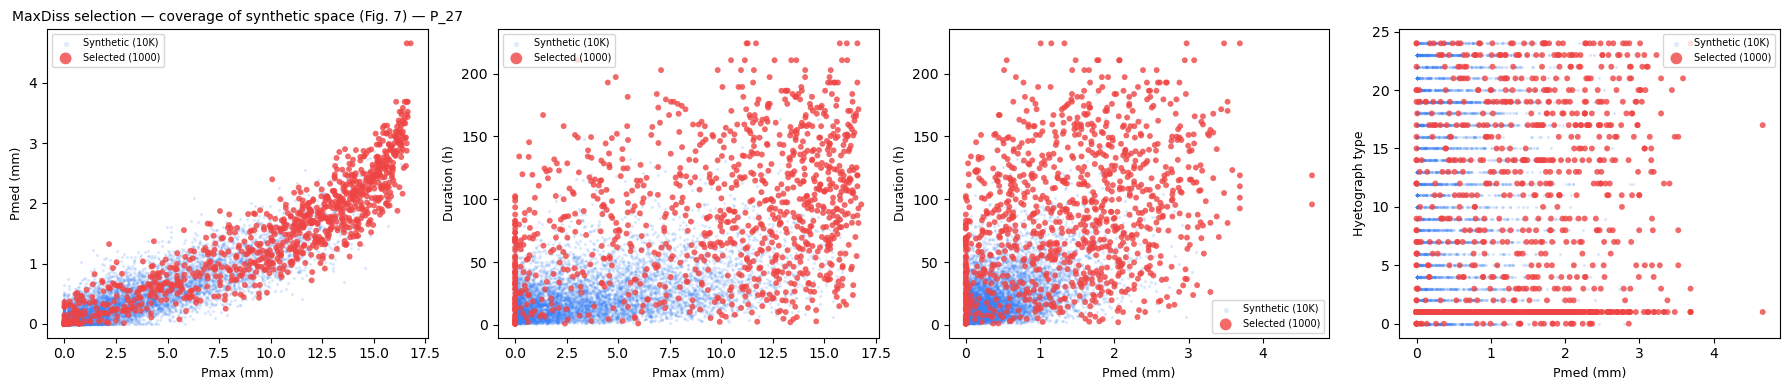

In [2]:
events = pd.read_csv(EVENTS_DIR / 'events_selected.csv', index_col=0)
synth  = pd.read_csv(EVENTS_DIR / 'events_synthetic_sample.csv', index_col=0)

# Gauge P_27 (station 1) — reference in the paper (Figure 7)
sel  = events[['Pmax1','Pmed1','Duracion1','Tipo1']].copy()
samp = synth[['Pmax1','Pmed1','Duracion1','Tipo1']].copy()

print(f'Synthetic pool (~1M, sample available): {len(samp):,}')
print(f'Events selected by MaxDiss: {len(sel)}')
print(f'  Note: Navas et al. (2024) select 625; this dataset contains {len(sel)} events.')

# Reproduce Figure 7 from Navas et al. (2024)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

pairs = [
    ('Pmax1',  'Pmed1',     'Pmax (mm)',  'Pmed (mm)'),
    ('Pmax1',  'Duracion1', 'Pmax (mm)',  'Duration (h)'),
    ('Pmed1',  'Duracion1', 'Pmed (mm)',  'Duration (h)'),
    ('Pmed1',  'Tipo1',     'Pmed (mm)',  'Hyetograph type'),
]

for ax, (xc, yc, xl, yl) in zip(axes, pairs):
    ax.scatter(samp[xc], samp[yc], s=2, alpha=0.12, c='#3b82f6',
               label=f'Synthetic ({len(samp)//1000}K)', rasterized=True)
    ax.scatter(sel[xc],  sel[yc],  s=18, alpha=0.8,  c='#ef4444',
               edgecolors='none', label=f'Selected ({len(sel)})', zorder=3)
    ax.set_xlabel(xl, fontsize=9); ax.set_ylabel(yl, fontsize=9)
    ax.legend(fontsize=7, markerscale=2)

axes[0].set_title('MaxDiss selection — coverage of synthetic space (Fig. 7) — P_27',
                  fontsize=10)
plt.tight_layout(); plt.show()

## MaxDiss demonstration with `pyhydra`

MaxDiss demo: 50 events selected from 10,000 (4D space, P_27)


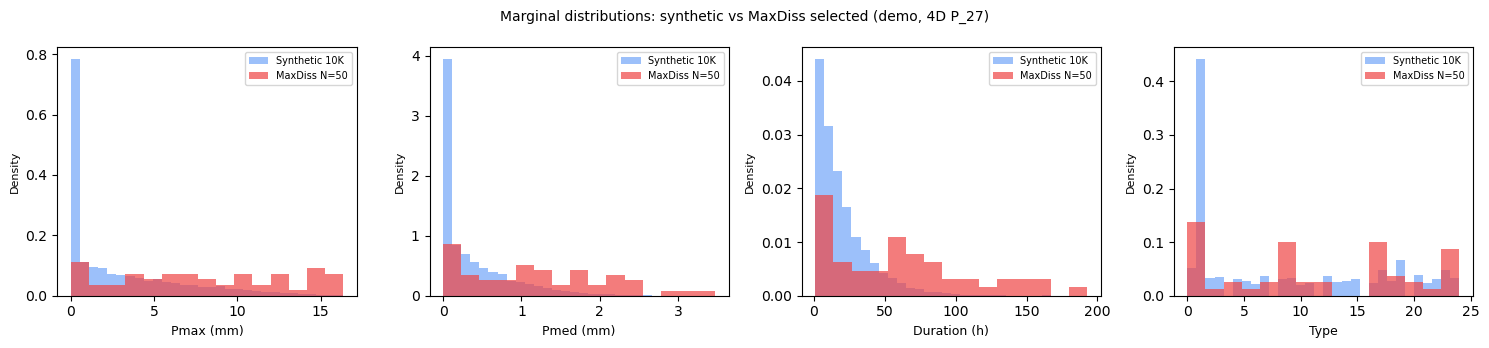

In [3]:
from pyhydra.climate.hybrid_downscaling.reconstruction import maxdiss
from sklearn.preprocessing import MinMaxScaler

feat_cols = ['Pmax1','Pmed1','Duracion1','Tipo1']
X   = samp[feat_cols].values
sc  = MinMaxScaler()
X_n = sc.fit_transform(X)

sel_data, sel_idx = maxdiss(
    X_n, n_select=50,
    scalar_cols=list(range(X_n.shape[1])),
    seed_positions=[0],
)
print(f'MaxDiss demo: {len(sel_idx)} events selected from {len(X):,} (4D space, P_27)')

# Compare marginal distributions: full synthetic vs MaxDiss selected
labels = ['Pmax (mm)', 'Pmed (mm)', 'Duration (h)', 'Type']
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, col, label in zip(axes, feat_cols, labels):
    ax.hist(samp[col], bins=30, density=True, alpha=0.5,
            color='#3b82f6', label='Synthetic 10K')
    ax.hist(samp.iloc[sel_idx][col], bins=15, density=True, alpha=0.7,
            color='#ef4444', label=f'MaxDiss N=50')
    ax.set_xlabel(label, fontsize=9); ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7)

plt.suptitle('Marginal distributions: synthetic vs MaxDiss selected (demo, 4D P_27)',
             fontsize=10)
plt.tight_layout(); plt.show()